# Numerical Simulations

In [1]:
import imageio.v2 as imageio
import importlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import concurrent.futures
import os

from IPython.display import Image
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
from functools import partial

import numerical_simulations_analysis as nm
importlib.reload(nm)

# Remove warnings
import warnings
warnings.simplefilter("ignore")

np.set_printoptions(threshold=np.inf)

# Uncomment the following lines if you want to use LaTeX for rendering text
# os.environ["PATH"] += os.pathsep + '/Library/TeX/texbin'
# plt.rcParams['text.usetex'] = True
# plt.rcParams['font.family'] = 'serif'

## 0. Get and read the data

In [2]:
id_start, id_end = 0, 200

# Data information
data_directory = './Projet_1/'
timev = np.linspace(0, 1000, 201)  # Time/steps Mys

# Information about the numerical simulation
simulation_name = 'Af_v1_01/DUMPS'  # Name of the simulation

## Read the data with InitialConditions

#### If there are multiple galaxies, InitialConditions uses a clusterer (HDBSCAN) to figure out which particle belongs to which galaxy using initial conditions.

In [3]:
initial = nm.InitialConditions(data_directory + simulation_name, 2, abbs=["stars"], fill=6)
# To rotate the particles, use the rotate_particles method as shown below (the values are only examples).
# initial.rotate_particles('x', 20)

def data_read(sim, idnum):
    sim.read_one_data(idnum)
    # To rotate particles, add the rotate one timestep method as shown below (the values are only examples).
    # sim.rotate_one_timestep('x', 20, idnum)

# List of idnums. First line is for if they're spaced at irregular intervals (old GCD+ output).
idnum_arr = np.loadtxt(f"{os.path.join(data_directory, simulation_name)}/tzstep.dat", dtype=int, usecols=0)
# idnum_detilted = "idnum_arr" + "r" # Add r for detilted data
# idnum_arr = list(range(id_start, id_end+1))

if __name__ == '__main__':
    sim = nm.Simulation(os.path.join(data_directory, simulation_name), id_start, id_end, 2, initial_conditions=initial,
                        abbs=["stars"], intervals=2e7, idnum_arr=idnum_arr, fill=6)
    partial_dr = partial(data_read, sim)

    # We use multiprocessing to speed things up (very marginal gains at low resolution).
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = [executor.submit(partial_dr, idnum) for idnum in range(len(idnum_arr))]

        # This is to see if we are raising an exception, as ThreadPoolExecutor takes care of it otherwise.
        for future in concurrent.futures.as_completed(futures):
            result = future.result()

## Read the data with split

#### If there are multiple galaxies, split uses the particles' id to differentiate between the galaxies (GCD+ assigns a unique id to each particle, and will assign ids from 0 to n-1 to particles from galaxy 1 and ids from n to m to particles from galaxy 2. The "split value" (i.e. n) is different for each particle type.)

In [ ]:
def data_read(sim, idnum):
    sim.read_one_data(idnum)
    # To rotate particles, add the rotate one timestep method as shown below (the values are only examples).
    # sim.rotate_one_timestep('x', 20, idnum)

# List of idnums. First line is for if they're spaced at irregular intervals (old GCD+ output).
idnum_arr = np.loadtxt(f"{os.path.join(data_directory, simulation_name)}/tzstep.dat", dtype=int, usecols=0)
# idnum_arr = list(range(id_start, id_end+1))

if __name__ == '__main__':
    sim = nm.Simulation(os.path.join(data_directory, simulation_name), id_start, id_end, 2, split={'dark': 256000},
                        abbs=["dark"], intervals=2e7, idnum_arr=idnum_arr, fill=6)
    partial_dr = partial(data_read, sim)

    # We use multiprocessing to speed things up (very marginal gains at low resolution).
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = [executor.submit(partial_dr, idnum) for idnum in range(len(idnum_arr))]

        # This is to see if we are raising an exception, as ThreadPoolExecutor takes care of it otherwise.
        for future in concurrent.futures.as_completed(futures):
            result = future.result()

## Split galaxies 


In [4]:
output_1 = "Af_v1_01/DUMPS"
output_2 = "Af_v1_02/DUMPS"
sim.split_all_timesteps(data_directory + output_1, data_directory + output_2, abb = 'stars')

100%|██████████| 151/151 [07:38<00:00,  3.04s/it]


## Aligner avec le pic de densité (OBSOLETE)

In [ ]:
run_name = "planxy/centered_dm"  # Name of the run
id_start, id_end = 0, 200
abb = 'd'
if abb == 's':
    plot_dir = os.path.join(data_directory, simulation_name, "density/stars", run_name)
if abb == 'g':
    plot_dir = os.path.join(data_directory, simulation_name, "density/gas", run_name)
if abb == 'd':
    plot_dir = os.path.join(data_directory, simulation_name, "density/dark_matter", run_name)
if abb == 'f':
    plot_dir = os.path.join(data_directory, simulation_name, "density/feedback", run_name)

os.makedirs(plot_dir, exist_ok=True)
if abb == 'f':
    for t in tqdm(sim.timesteps):
    # Center on dark matter density peak
        sim.adjust_center_with_density_peak(t, galaxy='gal1', abb='dark', nbins=100)
        
        # Now plot
        t.plot_feedback_density( 
            plot_dir=plot_dir, 
            save=True, 
            x_lim=(-30, 30), 
            y_lim=(-30, 30), 
            z_lim=(-30, 30),
            vmin=0.75, 
            vmax=3.75, 
            fig_size=(5, 6), 
            galaxy="all", 
            cmap='hot', 
            nbins=400, 
            multiplot=False
        )
# For all other abbs.
else:
    for t in tqdm(sim.timesteps):
        # Center on dark matter density peak
        sim.adjust_center_with_density_peak(t, galaxy='gal1', abb='dark', nbins=100)
        
        # Now plot
        t.plot_density_distribution(
            abb='dark', 
            plot_dir=plot_dir, 
            save=True, 
            x_lim=(-30, 30), 
            y_lim=(-30, 30), 
            z_lim=(-30, 30),
            vmin=0.75, 
            vmax=3.75, 
            fig_size=(5, 6), 
            galaxy="all", 
            cmap='hot', 
            nbins=400, 
            multiplot=False
        )

NameError: name 'os' is not defined

## Pic de densité 2

il faudra premièrement enregistrer les pics de densité de surface pour chaque timestep. Puisque la matière sombre constitue la majorité de la simulation, elle est lourde en RAM et on veut éviter de les charger à chaque fois, alors on crée un fichier txt contenant les positions des pics, qui est bcp bcp bcp moins lourd.

In [4]:
directory = data_directory + simulation_name
# Create directories if they don't exist
os.makedirs(directory, exist_ok=True) 
file_path = os.path.join(directory, 'dmcenter.txt')

sim.compute_and_save_dm_centers(output_file=file_path)

Computing DM density peaks...


  0%|          | 0/151 [00:00<?, ?it/s]


KeyError: 'dark'

Si on a déjà le fichier dmcenter.txt, on peut juste le loader et éviter de loader le dm.

In [4]:
directory = data_directory + simulation_name
file_path = os.path.join(directory, 'dmcenter.txt')
sim.load_dm_centers(filename=file_path)
for t in tqdm(sim.timesteps):
    sim.center_on_saved_dm_peak(t)


Loaded pic DM


100%|██████████| 151/151 [00:00<00:00, 284.08it/s]


## 1. Simulation figures

### 1.1 Density figures

In [6]:
run_name = "planxy-dmcenteredtest"  # Name of the run
id_start, id_end = 0, 200
abb = 's'
if abb == 's':
    plot_dir = os.path.join(data_directory, simulation_name, "density/stars", run_name)
if abb == 'g':
    plot_dir = os.path.join(data_directory, simulation_name, "density/gas", run_name)
if abb == 'd':
    plot_dir = os.path.join(data_directory, simulation_name, "density/dark_matter/testcenter", run_name)
if abb == 'f':
    plot_dir = os.path.join(data_directory, simulation_name, "density/feedback", run_name)

os.makedirs(plot_dir, exist_ok=True)

# If, for some reason, you want to plot feedback density.
if abb == 'f':
    for t in sim.timesteps[1:]:
        t.plot_feedback_density(plot_dir=plot_dir, save=True, x_lim=(-15, 15), y_lim=(-15, 15), cmap='hot', nbins=500,
                                colorbar=True, dpi=400, vmin=1, vmax=3)
# For all other abbs.
else:
    for t in sim.timesteps:
        t.plot_density_distribution(abb, plot_dir=plot_dir, save=True, x_lim=(-30, 30), y_lim=(-30, 30), z_lim=(-30, 30),
                                    vmin=0.75, vmax=3.75, fig_size=(5, 6), galaxy="all", cmap='hot', nbins=400, multiplot=False)

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

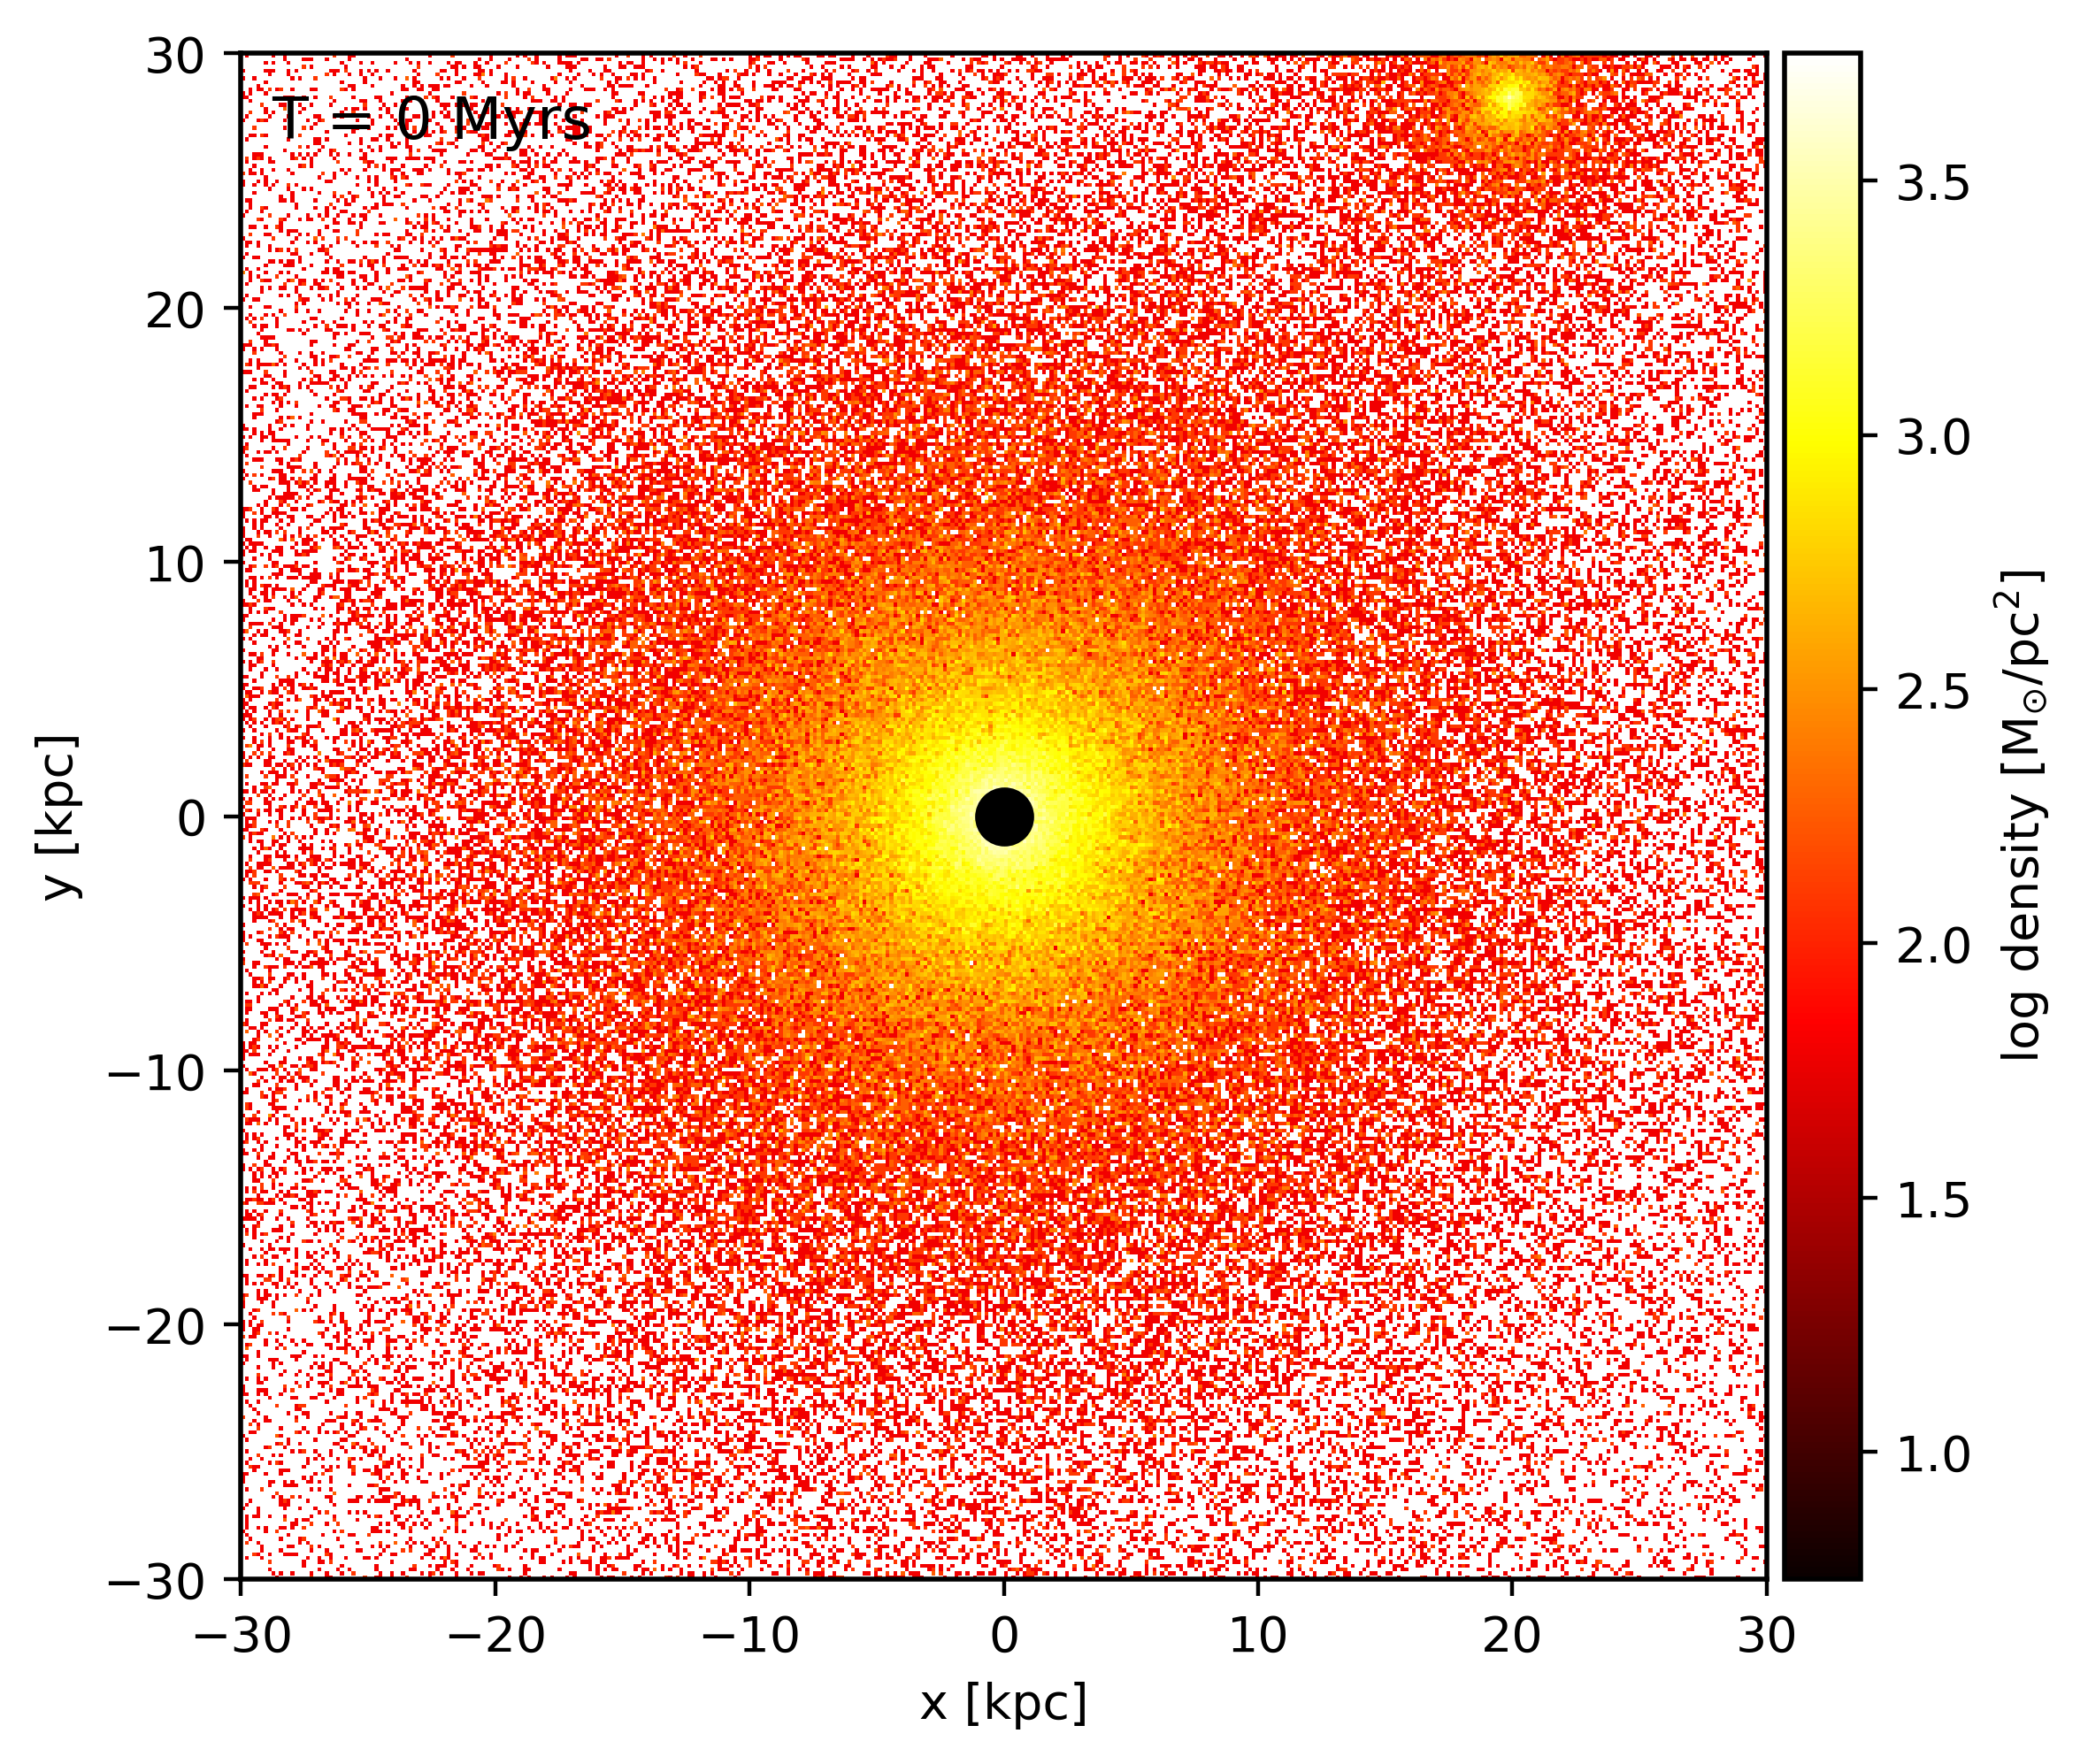

<Figure size 640x480 with 0 Axes>

KeyboardInterrupt: 

In [6]:
run_name = "planxy"  # Name of the run
id_start, id_end = 0, 200
abb = 'd'
if abb == 's':
    plot_dir = os.path.join(data_directory, simulation_name, "density/stars", run_name)
if abb == 'g':
    plot_dir = os.path.join(data_directory, simulation_name, "density/gas", run_name)
if abb == 'd':
    plot_dir = os.path.join(data_directory, simulation_name, "density/dark_matter/test", run_name)
if abb == 'f':
    plot_dir = os.path.join(data_directory, simulation_name, "density/feedback", run_name)

os.makedirs(plot_dir, exist_ok=True)
for t in sim.timesteps:
    t.plot_density_distribution(abb, plot_dir=plot_dir, make_plot=True, x_lim=(-30, 30), y_lim=(-30, 30), z_lim=(-30, 30),
                                vmin=0.75, vmax=3.75, fig_size=(5, 6), galaxy="all", cmap='hot', nbins=400, multiplot=False)

### 1.2 Velocity figures

In [ ]:
vel_type = "total"    # los (line of sight), rad (radial), circ (circular), total
id_start, id_end = 0, 200
abb = 's'
# If we want a more specific directory (e.g. .../velocity/abb/vel_type/20degrees), it must be added manually.
if abb == 's':
    plot_dir = os.path.join(data_directory, simulation_name, "velocity/stars/vel", vel_type)    # The /vel is to have separate subdirectories for velocity and velocity dispersion 
if abb == 'g':
    plot_dir = os.path.join(data_directory, simulation_name, "velocity/gas/vel", vel_type)
if abb == 'd':
    plot_dir = os.path.join(data_directory, simulation_name, "velocity/dark_matter/vel", vel_type)
if abb == 'f':
    plot_dir = os.path.join(data_directory, simulation_name, "velocity/feedback/vel", vel_type)

os.makedirs(plot_dir, exist_ok=True)

for t in sim.timesteps:
    t.plot_velocity(abb, vel_type, plot_dir, v_sys=0, save=True, cmap='turbo', x_lim=(-30, 30), y_lim=(-30, 30),
                    vmin=0, vmax=5, nbins=400, colorbar=True, galaxy='all')

### 1.3 Velocity dispersion figures

In [ ]:
vel_type = "los"    # los (line of sight), rad (radial), circ (circular), total
id_start, id_end = 0, 200
abb = 'f'
# If we want a more specific directory (e.g. .../velocity/abb/vel_type/20degrees), it must be added manually.
if abb == 's':
    plot_dir = os.path.join(data_directory, simulation_name, "velocity/stars/disp", vel_type)   # The /disp is to have separate subdirectories for velocity and velocity dispersion
if abb == 'g':
    plot_dir = os.path.join(data_directory, simulation_name, "velocity/gas/disp", vel_type)
if abb == 'd':
    plot_dir = os.path.join(data_directory, simulation_name, "velocity/dark_matter/disp", vel_type)
if abb == 'f':
    plot_dir = os.path.join(data_directory, simulation_name, "velocity/feedback/disp", vel_type)

for t in sim.timesteps:
    t.plot_velocity_dispersion(abb, vel_type, plot_dir, save=False, cmap='turbo', x_lim=(-30, 30), y_lim=(-30, 30),
                    vmin=-40, vmax=40, nbins=400, colorbar=True, galaxy='all')

## 2. Get Simulation GIFs

In [ ]:
data_directory = "./Impact_formation/DATA/"

simulation_name = 'Af_v2hr'

# Name of the subdirectory the files are in.
dirname = "density_comp"
# Whether it's density or velocity we're looking at
dens_or_vel = 'density'

id_start, id_end = 0, 200
abb = 'g'
if abb == 's':
    plot_dir = os.path.join(data_directory, simulation_name, dens_or_vel, "stars", dirname)
if abb == 'g':
    plot_dir = os.path.join(data_directory, simulation_name, dens_or_vel, "gas", dirname)
if abb == 'd':
    plot_dir = os.path.join(data_directory, simulation_name, dens_or_vel, "dark_matter", dirname)
if abb == 'f':
    plot_dir = os.path.join(data_directory, simulation_name, dens_or_vel, 'feedback', dirname)

# Pour les gifs de Impact_formation
plot_dir = os.path.join(data_directory, simulation_name, "sfr/density_comp")

if abb == 'f':
    idump = np.arange(id_start + 1, id_end + 1)
else:
    # For new GCD+ output
    # idump = np.arange(id_start, id_end + 1)

    # For old GCD+ output
    idump = np.loadtxt(f"{os.path.join(data_directory, simulation_name)}/tzstep.dat", dtype=int, usecols=0)

images = []

for idum in idump[6:]:  # If you don't have images for all idnums, add a [start:] after idump, where start is the starting idnum
    image_path = plot_dir + f"/sfr_dens_{idum}.png"
    images.append(imageio.imread(image_path))

def check_file(file):
    """
    Check if file alreday exists and returns a new path
    that do not exists by adding a number at the end.
    Otherwise it returns the same path.
    """
    fil_name, fil_ext = os.path.splitext(file)
    new_file = file
    i = 2
    while os.path.isfile(new_file):
        new_file = fil_name + f'_{i}' + fil_ext
        i += 1
    return new_file

# Specify the delay between frames in seconds. The minimum is 0.01.
delay = 0.25

# Create the GIF file
gif_path = plot_dir + f'/{simulation_name}_animation_{int(delay * (id_end - id_start))}s.gif'
gif_path = check_file(gif_path)

with imageio.get_writer(gif_path, mode='I', duration=(delay*1000)) as writer:   # 'duration' uses milliseconds.
    for image in images:
        writer.append_data(image)

print(gif_path, 'created')

In [ ]:
# Display GIF
with open(gif_path, 'rb') as f:
    display(Image(data=f.read(), format='gif'))

## 3. Custom Arp_143 figures

In [ ]:
importlib.reload(nm)
# Load the data
simulation_name = 'Run01'  # Simulation name
fig_dir = f'{data_directory}/{simulation_name}/Figures/'
os.makedirs(fig_dir, exist_ok=True)

### 3.1 Morphology Multifigure

In [ ]:
abb = 'g'  # s: stars, g: gas, d: dark matter, f: feedback

run_name = "article_multifigures"

# List of timesteps you want to plot
# 1 : timesteps = [16, 34, 50, 72]
# 2 : timesteps = [94, 102, 108, 145]
timesteps = [16, 34, 50, 72]  # Adjust these as needed

vmin, vmax = 1, 3

# Path for saving the figures
if abb == 's':
    plot_dir = os.path.join(data_directory, simulation_name, "stars", run_name)
    title = 'Stars'
if abb == 'g':
    plot_dir = os.path.join(data_directory, simulation_name, "gas", run_name)
    title = 'Gas'

# Create the directory if it does not exist
os.makedirs(plot_dir, exist_ok=True)

# Second pass: create plots
for i, timestep in enumerate(timesteps):
    simulation = nm.Timestep(data_directory + simulation_name, timestep, timev[timestep], 1)
    simulation.read_data(initial_conditions=initial)
    simulation.rotate_particles('x', 20)
    simulation.rotate_particles('z', -25)
    
    # Plot density distribution
    simulation.plot_density_distribution(
        abb=abb, save=True, plot_dir=plot_dir, nbins=400, colorbar=False, fig_size=(4, 5),
        x_lim=(-50, 50), y_lim=(-50, 150), z_lim=(-50, 50), vmin=vmin, vmax=vmax, dpi=500
    )

# Set up the figure and GridSpec
fig = plt.figure(figsize=(8, 10))
gs = GridSpec(3, 2, figure=fig, height_ratios=[1, 1, 0.05], width_ratios=[1, 1])

for i, timestep in enumerate(timesteps):
    ax = fig.add_subplot(gs[i // 2, i % 2])
    img = plt.imread(f'{plot_dir}/{abb}_{str(timestep).zfill(3)}.png')
    ax.imshow(img)
    ax.axis('off')

# Add a single colorbar
cmap = mpl.cm.hot
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cax = fig.add_subplot(gs[-1, :])
cax.set_title(title)
cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
             cax=cax, orientation='horizontal', label=r'log density [M$_{\odot}$/pc$^2$]')

plt.tight_layout()
plt.savefig(f'{fig_dir + abb}_multifig_1', dpi=400, bbox_inches='tight')
plt.show()

### 3.2 Abondances

In [ ]:
# Load a few timesteps. This is not needed if the timesteps have already been loaded.
sim = nm.Simulation(os.path.join(data_directory, simulation_name), 86, 102, 1, initial_conditions=initial)
sim.read_data()
sim.rotate_particles('x', 20)
sim.rotate_particles('z', -25)
# simulation = sim

#### Abundances

In [ ]:
element = 'N'   # 'N' or 'O'

if element == 'N':
    name_file = 'logN'
    name_label = 'log(N/O)'
elif element == 'O':
    name_file = '12+logO'
    name_label = '12+log(O/H)'

abb = 's'  # s: stars, g: gas

if abb == 's':
    abb_name = 'stars'
elif abb == 'g':
    abb_name = 'gas'

lim = 18    # The limits of the axes.
rings = True    # Whether we plot rings to help with visualising distance.

# Rough estimates of the correct range for the cmap (vmin to vmax).
# Gas:
#   N: -1.15 to -0.85
#   O: 8.2 to 9.2
# Stars:
#   N: -1.15 to -1
#   O: 8 to 8.6
vmin, vmax = -1.15, -1

# Path for saving the figures
plot_dir = os.path.join(data_directory, simulation_name, "abondances", abb_name, name_file)
os.makedirs(plot_dir, exist_ok=True)

if element == 'N':
    for timestep in sim.timesteps:
        timestep.plot_log_N(abb, plot_dir=plot_dir, save=True, nbins=300, colorbar=True,
                                        x_lim=(-lim, lim), y_lim=(-lim, lim), vmin=vmin, vmax=vmax,
                                        galaxy='gal1', max_dist=np.inf, log_density_threshold=1, rings=rings)
elif element == 'O':
    for timestep in sim.timesteps:
        timestep.plot_12_plus_log_O(abb, plot_dir=plot_dir, save=True, nbins=300, colorbar=True,
                                        x_lim=(-lim, lim), y_lim=(-lim, lim), vmin=vmin, vmax=vmax,
                                        galaxy='gal1', max_dist=np.inf, log_density_threshold=1, rings=rings)

#### Abundances multifigures

In [ ]:
# log(N/O)
element = 'N'

name_file = 'logN'
name_label = 'log(N/O)'

abb = 's'  # s: stars, g: gas
lim = 18

# List of timesteps you want to plot
timesteps = [50, 52, 54]

# Rough estimates of the correct range for the cmap (vmin to vmax).
# Gas:
#   -1.15 to -0.85
# Stars:
#   -1.2 to -0.95
vmin, vmax = -1.2, -1

# Path for saving the figures
plot_dir = os.path.join(data_directory, simulation_name, "abondances")
os.makedirs(plot_dir, exist_ok=True)

for i, timestep in enumerate(timesteps):
    sim[timestep].plot_log_N(abb, plot_dir=plot_dir, save=True, nbins=300, colorbar=True,
                                    x_lim=(-lim, lim), y_lim=(-lim, lim), vmin=vmin, vmax=vmax,
                                    galaxy='gal1', max_dist=np.inf, log_density_threshold=1)

# Set up the figure and GridSpec
fig, axs = plt.subplots(1, len(timesteps), layout='constrained', figsize=(13, 4))

for i, timestep in enumerate(timesteps):
    ax = axs[i]
    img = plt.imread(f'{plot_dir}/{abb}_{str(timestep).zfill(3)}_{name_file}.png')
    ax.imshow(img)
    ax.axis('off')

cmap = mpl.cm.plasma
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# Create a new axis for the colorbar that matches the height of the image axes
divider = make_axes_locatable(axs[-1])  # Use the last axis for the colorbar
cax = divider.append_axes("right", size="7%", pad=0.1)  # Adjust the size and padding of the colorbar

cmap = mpl.cm.plasma
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
im1 = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

cbar = fig.colorbar(im1, cax=cax, orientation='vertical')
cbar.ax.set_aspect(12.9/abs(vmin-vmax))  # Adjust the vertical size of the colorbar
cbar.set_label(f"{name_label} (dex)")
cbar.set_ticks([-1.4, -1.3, -1.2, -1.1])

# Uncomment this line to remove the colorbar for the whole plot (each subplot has a cbar and without this line there's
# another one for the whole plot).
cbar.remove()

plt.savefig(f'{fig_dir + abb}_multifg_{name_file}_{timesteps}', dpi=400, bbox_inches='tight')
plt.show()

In [ ]:
# 12 + log(O/H)
element = 'O'

name_file = '12+logO'
name_label = '12+log(O/H)'

abb = 's'  # s: stars, g: gas
lim = 18

# List of timesteps you want to plot
timesteps = [50, 52, 54]

# Rough estimates of the correct range for the cmap (vmin to vmax).
# Gas:
#   8 to 9
# Stars:
#   8 to 8.6
vmin, vmax = -1.2, -1

# Path for saving the figures
plot_dir = os.path.join(data_directory, simulation_name, "abondances")
os.makedirs(plot_dir, exist_ok=True)

for i, timestep in enumerate(timesteps):
        sim[timestep].plot_12_plus_log_O(abb, plot_dir=plot_dir, save=True, nbins=300, colorbar=True,
                                        x_lim=(-lim, lim), y_lim=(-lim, lim), vmin=vmin, vmax=vmax,
                                        galaxy='gal1', max_dist=np.inf, log_density_threshold=1)

# Set up the figure and GridSpec
fig, axs = plt.subplots(1, len(timesteps), layout='constrained', figsize=(13, 4))

for i, timestep in enumerate(timesteps):
    ax = axs[i]
    img = plt.imread(f'{plot_dir}/{abb}_{str(timestep).zfill(3)}_{name_file}.png')
    ax.imshow(img)
    ax.axis('off')

cmap = mpl.cm.plasma
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# Create a new axis for the colorbar that matches the height of the image axes
divider = make_axes_locatable(axs[-1])  # Use the last axis for the colorbar
cax = divider.append_axes("right", size="7%", pad=0.1)  # Adjust the size and padding of the colorbar

cmap = mpl.cm.plasma
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
im1 = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

cbar = fig.colorbar(im1, cax=cax, orientation='vertical')
cbar.ax.set_aspect(12.9/abs(vmin-vmax))  # Adjust the vertical size of the colorbar
cbar.set_label(f"{name_label} (dex)")
cbar.set_ticks([-1.4, -1.3, -1.2, -1.1])

# Uncomment this line to remove the colorbar for the whole plot (each subplot has a cbar and without this line there's
# another one for the whole plot).
cbar.remove()

plt.savefig(f'{fig_dir + abb}_multifg_{name_file}_{timesteps}', dpi=400, bbox_inches='tight')
plt.show()

### 3.3 Abundance depending on the radius

In [ ]:
# graph of 12 + log(O/H) depending on the radius
abb = 'stars'  # stars or gas
max_dist = 15    # in kpc
points = 10     # The number of points we take between 0 and max_radius
galaxy="all"    # The galaxy around which we center ("gal1", "gal2", "all")
x_lim, y_lim = None, None   # The limits of the axis
save = True     # Wether we save the figure or not

# List of timesteps you want to plot. These must be loaded before running this code.
idnums = [53, 60, 70]

# Path for saving the figures
plot_dir = os.path.join(data_directory, simulation_name, "abondances")
os.makedirs(plot_dir, exist_ok=True)

interval = max_dist / (2 * points)

log_dictionnary = {}

for i in range(len(idnums)):
    idnum = idnums[i] - idnums[0]
    log_dictionnary[idnums[i]] = sim.timesteps[idnum].list_12_plus_log_x_radii(abb, 'O', points, interval, galaxy=galaxy)

plt.clf()
for key in log_dictionnary.keys():
    plt.plot(np.arange(0, max_dist, max_dist/points), log_dictionnary[key],
                label=f"t = {int(key * sim.intervals / 1e6)} Myrs", marker="o", linestyle="None")
plt.ylabel('12+log(O/H) (dex)')
plt.legend()
if x_lim:
    plt.xlim(x_lim)
if y_lim:
    plt.ylim(y_lim)
if save:
    plt.savefig(f"{plot_dir}/log_dist_stars.png")
    plt.close()
else:
    plt.show()

### 3.4 Abundance over time

In [ ]:
sim = nm.Simulation(os.path.join(data_directory, simulation_name), 0, 200, 1, initial_conditions=initial)
sim.read_data()
sim.rotate_particles('x', 20)
sim.rotate_particles('z', -25)

In [ ]:
plot_dir = os.path.join(data_directory, simulation_name, "abondances")
os.makedirs(plot_dir, exist_ok=True)
sim.plot_12_plus_log_x(['C', 'O', 'N', 'Ne', 'Mg', 'Si', 'Fe'], save=True, plot_dir=plot_dir)

## 4. Star Formation Rate

### 4.1 Sfr over time

<Figure size 640x480 with 0 Axes>

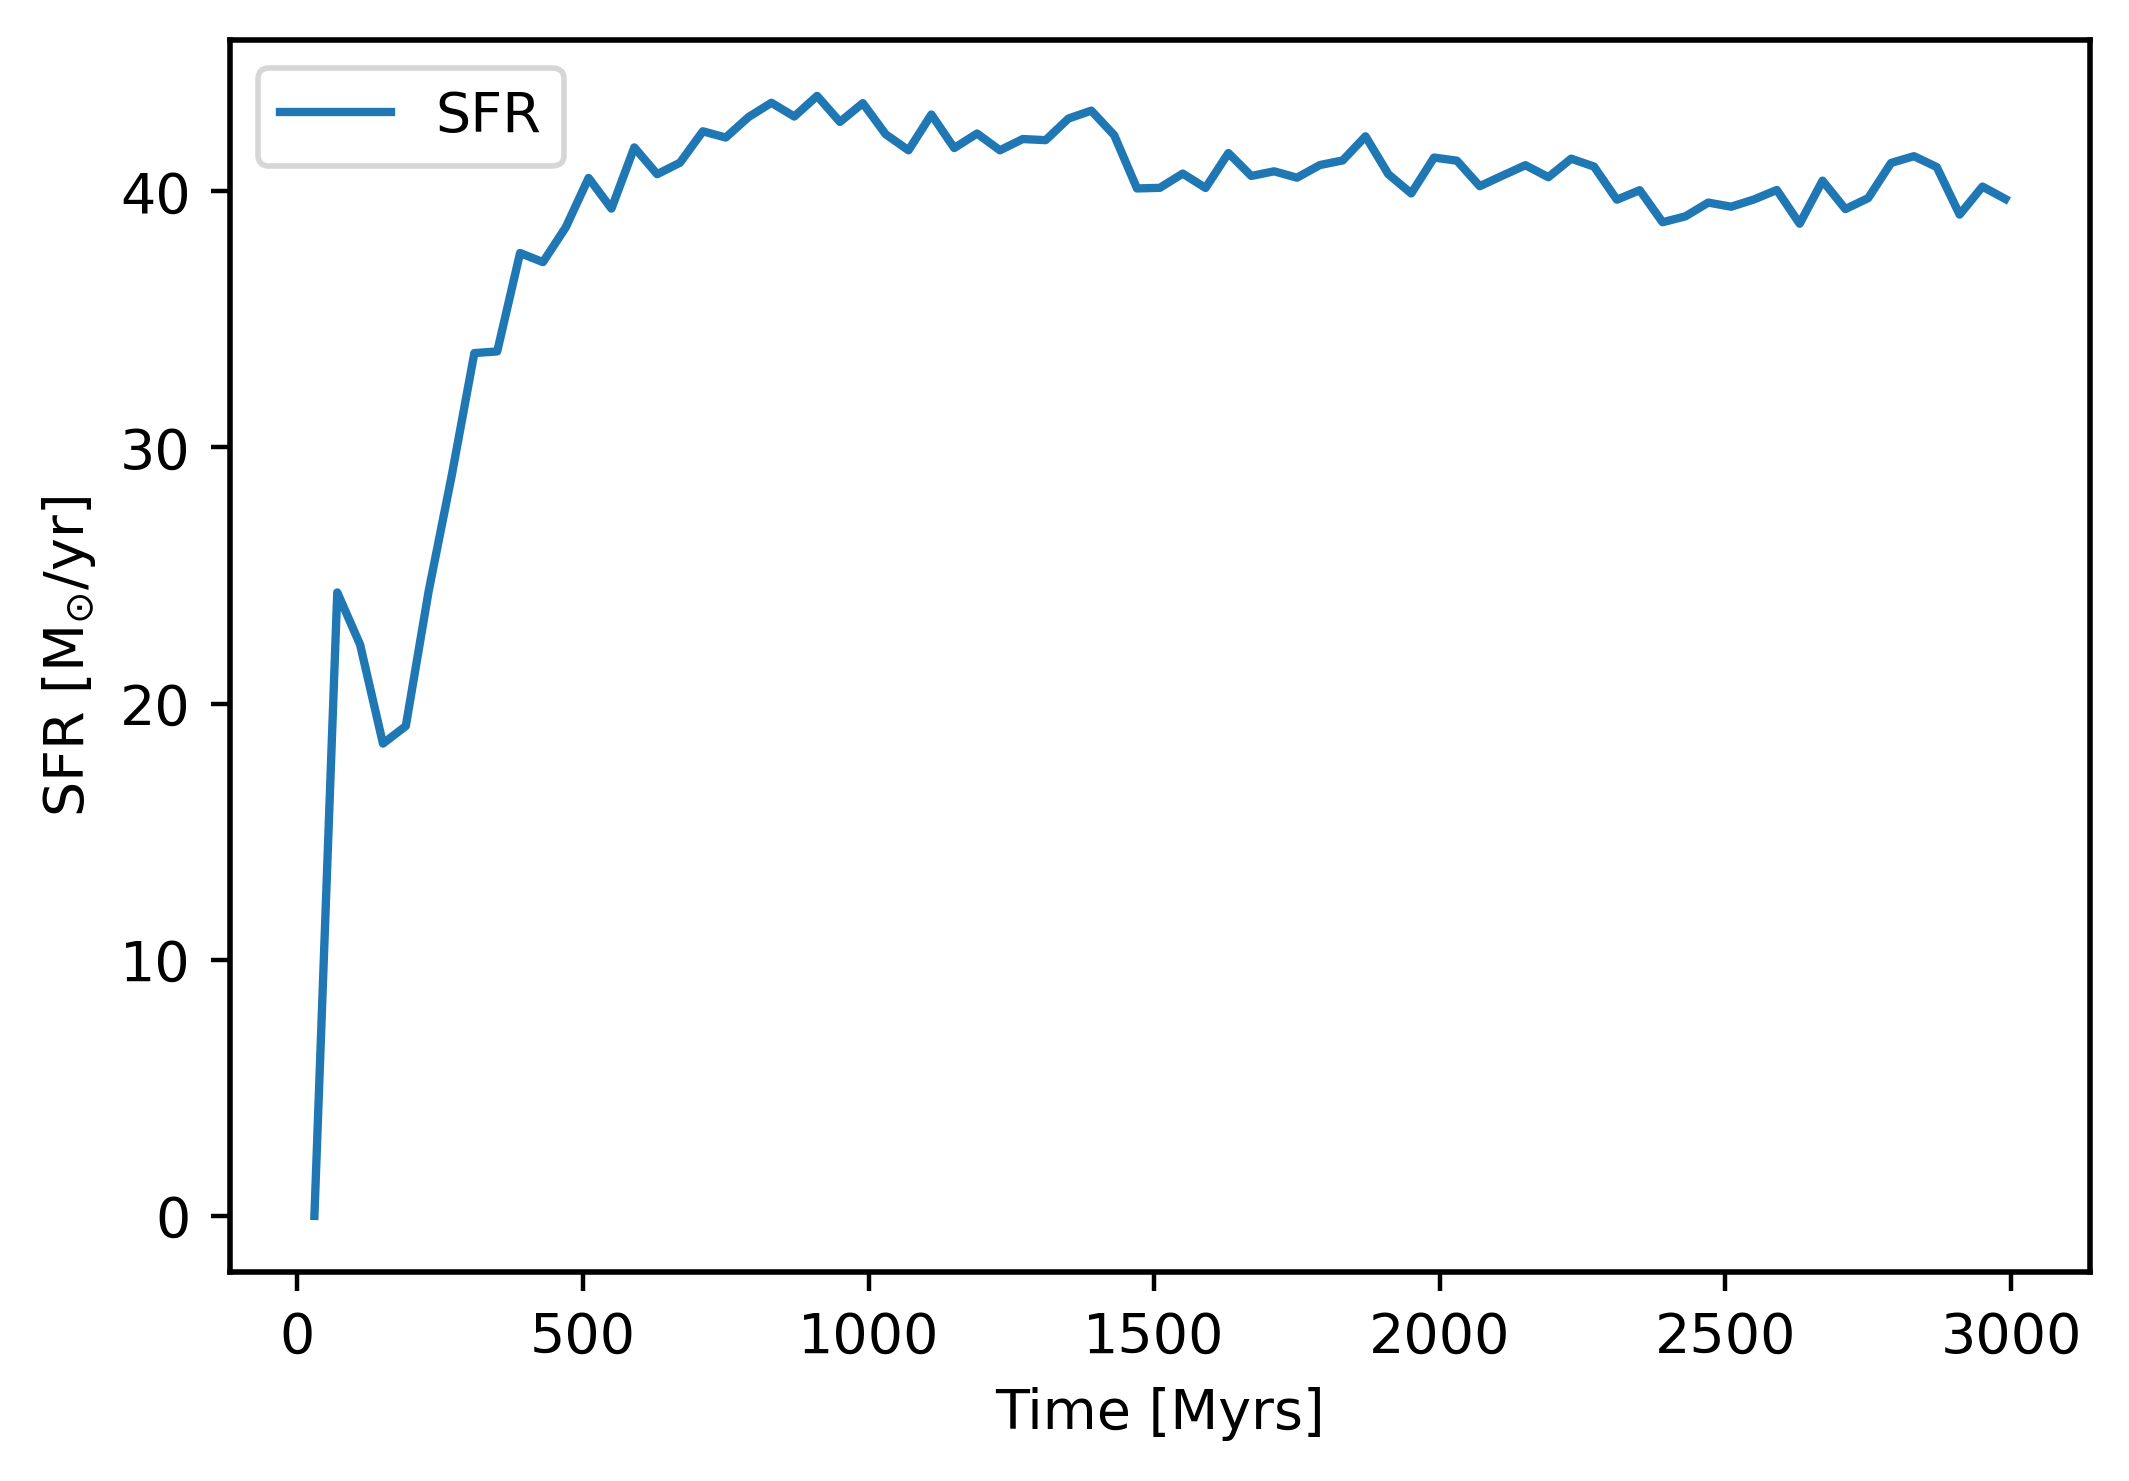

In [13]:
xlim = [0, 3000]
ylim = [0, 25]
sim.plot_sfr(interval=2)

In [10]:
plot_dir = os.path.join(data_directory, simulation_name, "sfr")
os.makedirs(plot_dir, exist_ok=True)

radii_list = (np.inf)
xlim = [0, 3000]
ylim = [0, 25]
sim.plot_sfr(plot_dir=plot_dir, save = True,galaxy="all", fig_size=(6, 5), interval=3, x_lim=xlim, y_lim=ylim)

<Figure size 640x480 with 0 Axes>

### 4.2 Sfr map

#### Creates maps of the star formation rate in the galaxy

In [14]:
plot_dir = os.path.join(data_directory, simulation_name, "sfr/map_dmcentered")
os.makedirs(plot_dir, exist_ok=True)
np.set_printoptions(threshold=np.inf)

nbtimesteps = 1    # How young does a star particle have to be in order to be considered "new", measured in timesteps.

for idnum in list(range(len(sim.idnums)))[nbtimesteps:]:
    sim.plot_sfr_map(idnum, plot_dir=plot_dir, save=True, x_lim=(-15, 15), y_lim=(-15, 15), vmin=0, vmax=3,# 7.5e-9,
                     cmap='hot', nbtimesteps=nbtimesteps, nbins=200, galaxy="all")

<Figure size 640x480 with 0 Axes>

### 4.3 Comparison bewteen runs

#### Loading the second run

In [5]:
id_start2, id_end2 = 0, 256

# Information about the numerical simulation
simulation_name2 = 'Y/DUMPS'  # Name of the simulation

initial2 = nm.InitialConditions(data_directory + simulation_name2, 1, abbs=["stars"], fill=6)
# To rotate the particles, use the rotate_particles method as shown below (the values are only examples).
# initial.rotate_particles('x', 20)

def data_read(sim, idnum):
    sim.read_one_data(idnum)
    # To rotate particles, add the rotate one timestep method as shown below (the values are only examples).
    # sim.rotate_one_timestep('x', 20, idnum)

# List of idnums. First line is for if they're not spaced at regular intervals.
idnum_arr = np.loadtxt(f"{os.path.join(data_directory, simulation_name2)}/tzstep.dat", dtype=int, usecols=0)
# idnum_arr = list(range(id_start, id_end+1))

if __name__ == '__main__':
    sim2 = nm.Simulation(os.path.join(data_directory, simulation_name2), id_start2, id_end2, 1, initial_conditions=initial2, abbs=["stars"],
                        intervals=2e7, idnum_arr=idnum_arr, fill=6)
    partial_dr = partial(data_read, sim2)

    # We use multiprocessing to speed things up (very marginal gains at low resolution).
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = [executor.submit(partial_dr, idnum) for idnum in range(len(idnum_arr))]

        # This is to see if we are raising an exception, as ThreadPoolExecutor hides it otherwise.
        for future in concurrent.futures.as_completed(futures):
            result = future.result()

Aligner la 2eme galaxie

In [6]:
directory = data_directory + simulation_name
file_path = os.path.join(directory, 'dmcenter.txt')
sim2.load_dm_centers(filename=file_path)
for t in tqdm(sim.timesteps):
    sim2.center_on_saved_dm_peak(t)


Loaded pic DM


100%|██████████| 151/151 [00:00<00:00, 598.69it/s]


#### Loading the third and fourth runs

In [ ]:
simulation_name3 = "Ar_v2"

idnum_arr = np.loadtxt(f"{os.path.join(data_directory, simulation_name3)}/tzstep.dat", dtype=int, usecols=0)

sim3 = nm.Simulation(os.path.join(data_directory, simulation_name3), id_start2, id_end2, 2, split={'stars': 128000}, abbs=["stars"],
                        intervals=2e7, idnum_arr=idnum_arr, fill=6)
sim3.read_data()

In [ ]:
simulation_name4 = "I"

idnum_arr = np.loadtxt(f"{os.path.join(data_directory, simulation_name4)}/tzstep.dat", dtype=int, usecols=0)

sim4 = nm.Simulation(os.path.join(data_directory, simulation_name4), id_start2, id_end2, 1, split={'stars': 128000}, abbs=["stars"],
                        intervals=2e7, idnum_arr=idnum_arr, fill=6)
sim4.read_data()

#### Making comparison graph. Outputs a graph of the SFR troughout the galaxies' evolution.

In [ ]:
interval = 3
x_lim = [0, 3000]
y_lim = [0, 3.25e1]

galaxy = 'all'

plot_dir = os.path.join(data_directory, simulation_name, f'sfr/{simulation_name} vs {simulation_name3}')
os.makedirs(plot_dir, exist_ok=True)

# Create a new variable called run_name which wll be the name of the run regardless of if it is detilted or not.
run_name = simulation_name
if simulation_name[-1] == 'r' or simulation_name[-1] == 'h':
    run_name = simulation_name[:-1]

times = []
temp_times = []

# For all timesteps
for i, time in enumerate(sim.dump_times[1:]):
    temp_times.append(time)

    if len(temp_times) == interval:
        times.append(np.mean(temp_times))
        temp_times = []

    if i + 1 == sim.len and temp_times:
        times.append(np.mean(temp_times))

# For all the distances we're interested in.
for dist in [2.5, 5, np.inf]:
    plt.clf()
    fig = plt.figure(figsize=(7,5), dpi=400)

    # Get the data for the runs we want
    sfr1 = sim.get_sfr(galaxy=galaxy, interval=interval, max_dist=dist)
    sfr2 = sim2.get_sfr(galaxy="all", interval=interval, max_dist=dist)
    sfr3 = sim3.get_sfr(galaxy=galaxy, interval=interval, max_dist=dist)    # We can have 2 or more runs being compared
    sfr4 = sim4.get_sfr(galaxy="all", interval=interval, max_dist=dist)[:-1]    # Sometimes you need to put a [:-1] for the arrays to be the same
                                                                                # size (idk why). It happens with the run I, and maybe others
    # PLot the runs we want to see
    plt.plot(times, sfr1, label=run_name+'h')
    plt.plot(times, sfr2, label='Iso_h')
    plt.plot(times, sfr3, label=run_name)
    plt.plot(times, sfr4, label='Iso')

    for i in range(1):
        # Plots a vertical line at the collision.
        plt.axvline(x=sim.get_distance_minima()[i, 1], color='black')

    plt.xlim(x_lim)
    plt.ylim(y_lim)

    plt.xlabel('Time [Myrs]')
    plt.ylabel(r'SFR [M$_{\odot}$ yr$^{-1}$]')

    plt.legend()

    # Create figure and file name
    if dist == np.inf:
        plt.title(f'Star formation rate over time in the main galaxy for the {run_name} run\n'
                  f'and the isolated run at both low and high resolution.')
        plt.savefig(f"{plot_dir}/sfr_over_time.png")
    else:
        plt.title(f'Star formation rate over time in the main galaxy for the {run_name} run\n'
                  f'and the isolated run at both low and high resolution inside a {dist} kpc\n'
                  f'radius from the center.')
        plt.savefig(f"{plot_dir}/sfr_over_time_{dist}.png")
    plt.close()

NameError: name 'simulation_name3' is not defined

Radial SFR Difference 

In [8]:
radialdiff_dir = "radial_diff_plots"
radialdiff_path = os.path.join(f"./Projet_1/Af_v1_01/DUMPS/sfr/", radialdiff_dir)
os.makedirs(radialdiff_path, exist_ok=True)
for idx, idnum in enumerate(sim.idnums[1:]):
    time = sim.dump_times[idx+1]

    sfr1, edges = sim.sfr_radial_profile(idnum=idnum)
    sfr2, _     = sim2.sfr_radial_profile(idnum=idnum)

    radialdiff_dir = "radial_diff_plots"
radialdiff_path = os.path.join("./Projet_1/Af_v1_01/DUMPS/sfr/", radialdiff_dir)
os.makedirs(radialdiff_path, exist_ok=True)

for idnum in sim.idnums[1:]:

    sfr1, edges = sim.sfr_radial_profile(idnum=idnum)
    sfr2, _     = sim2.sfr_radial_profile(idnum=idnum)

    diff = sfr1 - sfr2

    r_centers = 0.5 * (edges[1:] + edges[:-1])

    plt.figure()

    plt.plot(r_centers, diff, label="ΔSFR")
    plt.axhline(0, linestyle='--')

    plt.xlabel(r"r [kpc]")
    plt.ylabel(r"$\Delta$SFR [M$_{\odot}$ yr$^{-1}$ kpc$^{-2}$]")
    plt.title(f"Radial SFR difference (t = {time:.1f} Myr)")

    plt.legend()

    plt.savefig(f"{radialdiff_path}/sfr_radial_diff_{str(idnum).zfill(6)}.png")
    plt.close()

IndexError: list index out of range

#### SFR difference map. Makes a map of the main galaxy and plots a 2D histogramm showing the difference in SFR between two galaxies

In [7]:
nbins = 300

x_lim = (-15, 15)
y_lim = (-15, 15)
z_lim = (-15, 15)

nbtimesteps = 6
galaxy = "all"
cmap = "seismic"
vmin, vmax = -5e-9, 5e-9
dpi = 400

plan = 'xy'

run1 = simulation_name
run2 = simulation_name2

plot_dir = os.path.join(f"./Projet_1/Af_v1_01/DUMPS/sfr/mapcomptestall")
os.makedirs(plot_dir, exist_ok=True)

# For all the timesteps we want to study.
for idnum in list(range(len(sim.idnums)))[nbtimesteps+1:]:
    # Make the histogram
    sfr, x_edges, y_edges = sim.sfr_comp_map(sim2, idnum, plot_dir=plot_dir, save=True, nbtimesteps=nbtimesteps,
                                              x_lim=x_lim, y_lim=y_lim, z_lim=z_lim, plan=plan, make_plot=False)

    t = sim.timesteps[idnum]

    x_len = x_lim[1] - x_lim[0]
    y_len = y_lim[1] - y_lim[0]
    z_len = z_lim[1] - y_lim[0]

    # Change the x and y of the plot depending of the plane we're plotting.
    if plan == 'xy':
        x_plot_len, y_plot_len = x_len, y_len
        x_plot_lim, y_plot_lim = x_lim, y_lim
    if plan == 'yz':
        x_plot_len, y_plot_len = y_len, z_len
        x_plot_lim, y_plot_lim = y_lim, z_lim
    if plan == 'xz':
        x_plot_len, y_plot_len = x_len, z_len
        x_plot_lim, y_plot_lim = x_lim, z_lim

    plt.clf()
    fig = plt.figure(figsize=(6,6), dpi=dpi)
    ax = fig.add_subplot(autoscale_on=False, xlim=x_lim, ylim=y_lim)
    ax.set_aspect('equal')

    ax.set_title(f'T = {int(t.time)} Myrs', x=0.02, y=0.98, ha='left', va='top', pad=-2, color='w')

    # Renormalize the colormap to better fit our data.
    try:
        norm = mpl.colors.TwoSlopeNorm(vmin=np.nanmin(sfr), vcenter=0, vmax=np.nanmax(sfr))
    except ValueError:
        try:
            norm = mpl.colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=np.nanmax(sfr))
        except ValueError:
            norm = mpl.colors.TwoSlopeNorm(vmin=np.nanmin(sfr), vcenter=0, vmax=1)

    ax1 = ax
    im1 = ax1.pcolormesh(x_edges, y_edges, sfr.T, cmap=cmap, norm=norm)
    ax1.set_xlabel('x [kpc]')
    ax1.set_ylabel('y [kpc]')

    # Plot one marker per star (below the sfr plot).
    ax2 = ax
    x = t.particle_centered_positions["stars"][:, 0]
    y = t.particle_centered_positions["stars"][:, 1]
    z = t.particle_centered_positions["stars"][:, 2]

    # Adjusting for the plane we want to plot.
    if plan == 'xy':
        x, y = x, y
    if plan == 'yz':
        x, y = y, z
    if plan == 'xz':
        x, y = x, z

    ax2.plot(x, y, marker="o", color="0.5", linestyle="None", zorder=0, markersize=0.5)
    ax2.set_xlim(x_lim)
    ax2.set_ylim(y_lim)

    # Make a black background.
    ax3 = ax
    im3 = ax3.pcolormesh(np.linspace(-x_plot_len/2, x_plot_len/2, nbins),
                         np.linspace(-y_plot_len/2, y_plot_len/2, nbins),
                         np.ones([nbins, nbins]), cmap='hot', vmin=1, zorder=-10)

    # Color bar.
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(im1, cax=cax, orientation='vertical', pad=0.2)
    cbar.set_label(r'$\Delta$ SFR [M$_{\odot}$ kpc$^{-2}$ yr$^{-1}$]')

    plt.tight_layout()

    plt.savefig(f"{plot_dir}/sfr_{str(t.idnum).zfill(3)}.png")
    plt.close()

<Figure size 640x480 with 0 Axes>

#### SFR difference and density maps

In [10]:
nbtimesteps = 5

nbins_sfr = 135
nbins_dens = 250

plan = 'xy'

x_lim = (-30, 30)
y_lim = (-30, 30)
z_lim = (-30, 30)

figsize = (12, 6)
dpi = 400

cmap_sfr = 'seismic'
cmap_dens = 'hot'

vmin_dens = -8
vmax_dens = -6

vmin_sfr = -5e-9
vmax_sfr = 5e-9
auto_norm = True    # Whether the norm is made automatically for the SFR plot based on the min and max value.

def plot_sfr_dens(idnum, plot_dir, run_name):
        t = sim.timesteps[idnum]
        t_iso = sim2.timesteps[idnum]

        # We get data for the scatter plot based on the plane we are plotting.
        if plan == 'xy':
            ind1, ind2 = 0, 1
        elif plan == 'zy':
            ind1, ind2 = 2, 1
        elif plan == 'xz':
            ind1, ind2 = 0, 2
        else:
            raise ValueError("'plan' must be either 'xy', 'zy' or 'xz'.")

        x = t.particle_centered_positions['stars'][:,ind1]
        y = t.particle_centered_positions['stars'][:,ind2]

        # Getting histogram data of the difference in sfr.
        sfr, xedges, yedges = sim.sfr_comp_map(sim2, idnum, nbins=nbins_sfr, nbtimesteps=nbtimesteps, plan=plan, make_plot=False,
                                            x_lim=x_lim, y_lim=y_lim, z_lim=z_lim, galaxy='gal1')

        # Getting density histograms for both galaxies.
        dens_dict = t.plot_density_distribution('stars', x_lim=x_lim, y_lim=y_lim, z_lim=z_lim, make_plot=False)
        dens_dict_iso = t_iso.plot_density_distribution('stars', x_lim=x_lim, y_lim=y_lim, z_lim=z_lim, make_plot=False)

        plt.clf()
        fig, axes = plt.subplots(1, 3, figsize=figsize, dpi=dpi, sharey=True)

        # An assymetric norm for the density based on the minimum and maximum values (and centered on 0).
        if auto_norm:
            vmin_dens=min(np.nanmin(dens_dict[plan][0][dens_dict[plan][0] != -np.inf]),
                        np.nanmin(dens_dict_iso[plan][0][dens_dict_iso[plan][0] != -np.inf]))
            vmax_dens=max(np.nanmax(dens_dict[plan][0]),
                        np.nanmax(dens_dict_iso[plan][0]))

        # Plotting the density map of the isolated run.
        ax1 = axes[0]
        ax1.set_aspect('equal')
        ax1.set_title('Iso_h')
        im1 = ax1.pcolormesh(dens_dict_iso[plan][1], dens_dict_iso[plan][2], dens_dict_iso[plan][0], cmap=cmap_dens,
                            vmin=vmin_dens, vmax=vmax_dens)
        ax1.set_xlabel("[kpc]")
        ax1.set_ylabel("[kpc]")

        # Plotting the density map of the main run.
        ax2 = axes[1]
        ax2.set_aspect('equal')
        ax2.set_title(run_name)
        im2 = ax2.pcolormesh(dens_dict[plan][1], dens_dict[plan][2], dens_dict[plan][0], cmap=cmap_dens,
                            vmin=vmin_dens, vmax=vmax_dens)
        ax2.set_xlabel("[kpc]")

        # An assymetric norm for the cmap based on the minimum and maximum values (and centered on 0).
        if auto_norm:
            try:
                norm_sfr = mpl.colors.TwoSlopeNorm(vmin=np.nanmin(sfr), vcenter=0, vmax=np.nanmax(sfr))
            except ValueError:
                try:
                    norm_sfr = mpl.colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=np.nanmax(sfr))
                except ValueError:
                    norm_sfr = mpl.colors.TwoSlopeNorm(vmin=np.nanmin(sfr), vcenter=0, vmax=1)

        # The norm is simply based around the vmin and vmax arguments.
        else:
            norm_sfr = mpl.colors.TwoSlopeNorm(vmin=vmin_sfr, vcenter=0, vmax=vmax_sfr)

        # Plotting the SFR difference map.
        ax3 = axes[2]
        ax3.set_aspect('equal')
        ax3.set_title(r'$\Delta$ SFR')
        im3 = ax3.pcolormesh(xedges, yedges, sfr.T, cmap=cmap_sfr, norm=norm_sfr)
        ax3.set_xlabel("[kpc]")

        # Add a scatter plot of particles to the SFR dfference map.
        ax3.plot(x, y, marker='o', linestyle='none', markersize=0.5, color='grey', zorder=0)
        ax3.set_xlim(x_lim)
        ax3.set_ylim(y_lim)

        # Make a black background for the SFR difference map.
        ax3.pcolormesh(np.linspace(x_lim[0]/2, x_lim[1]/2, 2), np.linspace(y_lim[0]/2, y_lim[1]/2, 2), np.ones([2, 2]),
                    cmap='hot', vmin=1, zorder=-10)

        ax_cbar_sfr = fig.add_axes([0.15, 0.25, 0.7, 0.05])
        cbar_sfr = fig.colorbar(im3, cax=ax_cbar_sfr, orientation='horizontal')
        cbar_sfr.set_label(r'$\Delta$ SFR [M$_{\odot}$ kpc$^{-2}$ yr$^{-1}$]')

        ax_cbar_dens = fig.add_axes([0.15, 0.09, 0.7, 0.05])
        cbar_dens = fig.colorbar(im2, cax=ax_cbar_dens, orientation="horizontal")
        cbar_dens.set_label(r'log density [M$_{\odot}$/pc$^2$]')

        fig.subplots_adjust(top=1.15)

        fig.suptitle(f"Density plots for the isolated run and the {run_name} run and the difference in star formation between"
                f" them at {int(t.time)} myrs.", fontsize='large')

        plt.savefig(f"{plot_dir}/sfr_dens_{t.idnum}.png")
        plt.close()


    # Create a new variable for the name of the run that will be the same wheter the run is detilted or not.

run_name = simulation_name
if run_name[-1] == 'r':
    run_name = run_name[:-1]

plot_dir = os.path.join(data_directory, simulation_name, f"sfr/density_comp")
os.makedirs(plot_dir, exist_ok=True)

for idnum in tqdm(range(len(sim.idnums))[nbtimesteps+1:]):
    plot_sfr_dens(idnum, plot_dir=plot_dir, run_name=run_name)

  0%|          | 0/145 [00:00<?, ?it/s]


RuntimeError: Creating a sim object with InitialConditions does not allow to get new stars ina specific galaxy.